# Sismicidad en Chile: extracción, validación y ley de Gutenberg-Richter

**Pregunta.** ¿Qué patrones tiene la actividad sísmica de Chile, y qué tan completo y confiable es el catálogo nacional frente a una fuente internacional?

**Datos.**

- **Centro Sismológico Nacional (CSN).** Catálogo de sismos entre 2023 y 2025, extraído con web scraping desde sismologia.cl, que publica una página HTML por día.
- **Servicio Geológico de Estados Unidos (USGS).** Catálogo mundial consultado a través de su API pública, filtrado al recuadro de Chile y a magnitudes de 2,5 o más.

Este proyecto retoma y completa un [ejercicio de scraping de 2022](../archivo/web_scraping_sismos_2022/scraping_sismologia.ipynb), que había quedado incompleto.

**Método.** Extracción y limpieza del catálogo del CSN, análisis exploratorio en el tiempo y el espacio, emparejamiento de sismos entre ambas fuentes por tiempo y distancia, y ajuste de la ley de Gutenberg-Richter con el estimador de máxima verosimilitud de Aki y Utsu.

**Resultado principal.** El catálogo del CSN registra unos 7.400 sismos al año, trece veces más que el USGS dentro de Chile, y encuentra el 98% de los sismos que el USGS ubica en el país. La ubicación de los sismos dibuja la placa de Nazca hundiéndose bajo el continente. Sobre magnitud 4 se cumple la ley de Gutenberg-Richter con un valor b cercano a 1. Bajo ese umbral, el cambio de escala de magnitud del catálogo sesga la estimación, lo que muestra por qué hay que validar los datos antes de modelarlos.

## 1. Configuración y extracción

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dsaplicado import datos, sismos
from dsaplicado.graficos import AZUL_SECUENCIAL, COLORES, NEUTRO, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo

aplicar_estilo()
pd.set_option("display.float_format", "{:.2f}".format)

RAIZ = datos.raiz_repositorio()
CACHE = RAIZ / "datos" / "sismos"
FIGURAS = RAIZ / "01_analisis_de_datos" / "figuras"
ANIOS = [2023, 2024, 2025]

# La primera ejecución descarga una página por día con una pausa de un segundo entre solicitudes,
# para no sobrecargar el sitio. Después todo se lee desde la caché.
csn = pd.concat([sismos.cargar_catalogo_csn(a, CACHE) for a in ANIOS], ignore_index=True)
usgs = pd.concat([sismos.cargar_catalogo_usgs(a, CACHE) for a in ANIOS], ignore_index=True)
print(f"CSN: {len(csn):,} sismos. USGS: {len(usgs):,} sismos.")

CSN: 22,335 sismos. USGS: 2,650 sismos.


## 2. Limpieza y control de calidad

In [2]:
controles = {
    "sismos duplicados por identificador": int(csn["id"].duplicated().sum()),
    "sin magnitud": int(csn["magnitud"].isna().sum()),
    "sin coordenadas": int(csn[["latitud", "longitud"]].isna().any(axis=1).sum()),
    "diferencia entre hora local y UTC distinta de 3 o 4 horas": int(
        (~((csn["fecha_utc"] - csn["fecha_local"]).dt.total_seconds() / 3600).isin([3, 4])).sum()),
}
print(pd.Series(controles).to_string())

csn = csn.drop_duplicates("id").sort_values("fecha_utc").reset_index(drop=True)
csn["anio"] = csn["fecha_utc"].dt.year
fuera = ~csn["latitud"].between(-56, -17) | ~csn["longitud"].between(-76, -66)
print(f"\nSismos fuera del recuadro de Chile: {fuera.sum()}, que se excluyen para comparar con el USGS.")
csn = csn[~fuera].reset_index(drop=True)
print("\nTipos de magnitud en el CSN:")
print(csn["tipo_magnitud"].value_counts().to_string())

sismos duplicados por identificador                          0
sin magnitud                                                 0
sin coordenadas                                              0
diferencia entre hora local y UTC distinta de 3 o 4 horas    0

Sismos fuera del recuadro de Chile: 476, que se excluyen para comparar con el USGS.

Tipos de magnitud en el CSN:
tipo_magnitud
Ml     21163
Mw       623
Mww       47
M         17
Mlv        8
Mlh        1


El CSN informa la magnitud local (Ml) para la gran mayoría de los sismos y la magnitud de momento (Mw o Mww) para los más grandes. La magnitud de momento es la que mide mejor la energía de los grandes terremotos, porque la magnitud local se satura sobre 6 o 7.

## 3. ¿Dónde y cuándo tiembla?

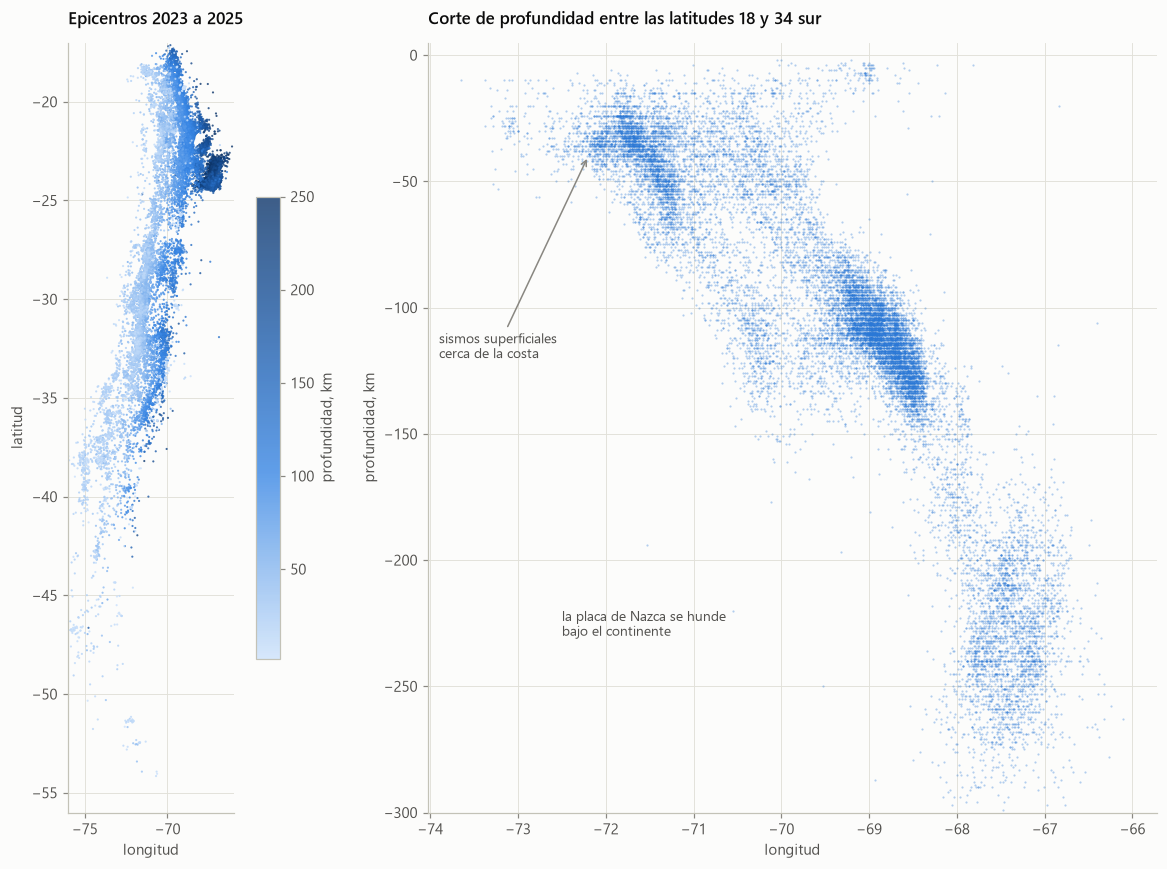

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), gridspec_kw={"width_ratios": [1, 1.6]})
orden = csn.sort_values("profundidad_km", ascending=False)
mapa = ax1.scatter(orden["longitud"], orden["latitud"], c=orden["profundidad_km"].clip(upper=250), s=2,
                   cmap=AZUL_SECUENCIAL, alpha=0.8, linewidths=0)
ax1.set_xlim(-76, -66)
ax1.set_ylim(-56, -17)
ax1.set_aspect(1 / np.cos(np.radians(33)))
ax1.set_xlabel("longitud")
ax1.set_ylabel("latitud")
ax1.set_title("Epicentros 2023 a 2025", fontsize=11)
barra = fig.colorbar(mapa, ax=ax1, shrink=0.6)
barra.set_label("profundidad, km")

zona = csn[csn["latitud"].between(-34, -18)]
ax2.scatter(zona["longitud"], -zona["profundidad_km"], s=2, color=COLORES[0], alpha=0.35, linewidths=0)
ax2.set_xlabel("longitud")
ax2.set_ylabel("profundidad, km")
ax2.set_ylim(-300, 5)
ax2.set_title("Corte de profundidad entre las latitudes 18 y 34 sur", fontsize=11)
ax2.annotate("sismos superficiales" + chr(10) + "cerca de la costa", xy=(-72.2, -40), xytext=(-73.9, -120), fontsize=9, color=TINTA_SECUNDARIA, arrowprops={"arrowstyle": "->", "color": TINTA_TENUE})
ax2.annotate("la placa de Nazca se hunde" + chr(10) + "bajo el continente", (-72.5, -230), fontsize=9, color=TINTA_SECUNDARIA)
fig.tight_layout()
fig.savefig(FIGURAS / "sismicidad_mapa.png", bbox_inches="tight", dpi=130)
plt.show()

**Lectura.** El mapa muestra la forma de Chile dibujada por sus sismos. El corte de profundidad revela la estructura que los explica: los sismos superficiales se concentran cerca de la costa y se hacen más profundos hacia el este. Esa franja inclinada, llamada zona de Wadati-Benioff, marca la placa de Nazca hundiéndose bajo la placa Sudamericana.

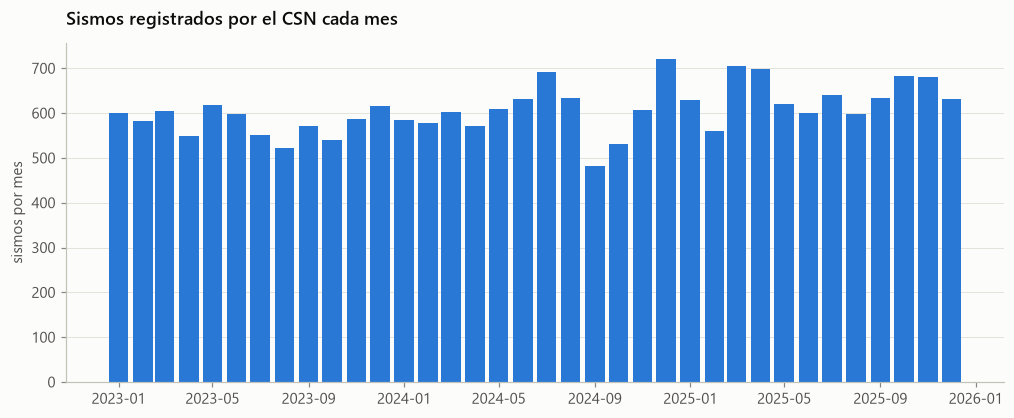

,fecha_local,referencia,magnitud,tipo_magnitud,profundidad_km
10868,2024-07-18 21:50:47,26 km al SE de San Pedro de Atacama,7.40,Mww,145.00
3874,2023-07-16 23:05:10,52 km al NE de Lonquimay,6.70,Mww,206.00
5722,2023-10-31 09:33:43,45 km al SO de Huasco,6.60,Mww,42.00
1617,2023-03-22 13:00:31,122 km al E de Socaire,6.50,Mww,240.00
1742,2023-03-30 14:33:04,109 km al NO de Cobquecura,6.40,Mww,22.00
4752,2023-09-06 20:48:05,10 km al SE de Tongoy,6.40,Mww,46.00
17501,2025-06-06 13:15:05,54 km al S de Diego de Almagro,6.40,Mww,66.00
13748,2024-12-13 20:38:18,52 km al SE de Curicó,6.30,Mww,114.00


In [4]:
mensual = csn.set_index("fecha_utc").resample("MS").size()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(mensual.index, mensual.values, width=25, color=COLORES[0])
ax.set_ylabel("sismos por mes")
ax.set_title("Sismos registrados por el CSN cada mes")
ax.grid(axis="x", visible=False)
plt.show()

grandes = csn.nlargest(8, "magnitud")[["fecha_local", "referencia", "magnitud", "tipo_magnitud", "profundidad_km"]]
grandes

In [5]:
regiones = {"Norte, 17 a 27 sur": (-27, -17), "Centro, 27 a 38 sur": (-38, -27), "Sur, 38 a 56 sur": (-56, -38)}
conteo_regional = pd.Series({nombre: csn["latitud"].between(sur, norte).sum() for nombre, (sur, norte) in regiones.items()})
(100 * conteo_regional / conteo_regional.sum()).round(0).rename("% de los sismos").to_frame()

,% de los sismos
"Norte, 17 a 27 sur",64.00
"Centro, 27 a 38 sur",33.00
"Sur, 38 a 56 sur",3.00


El número de sismos por mes se mantiene entre unos 480 y 720, sin secuencias de réplicas que dominen el período. El mayor sismo, de magnitud 7,4 en julio de 2024 cerca de San Pedro de Atacama, ocurrió a 145 km de profundidad. Los sismos de profundidad intermedia suelen generar pocas réplicas, a diferencia de los grandes terremotos superficiales.

## 4. Ley de Gutenberg-Richter

La ley dice que el número de sismos cae de forma exponencial con la magnitud: $\log_{10} N(M \geq m) = a - b\,m$. El valor $b$ suele estar cerca de uno, lo que significa que cada punto de magnitud adicional hay unas diez veces menos sismos.

Antes de estimar $b$ hay que encontrar la **magnitud de completitud**: bajo ella, la red no detecta todos los sismos, y la curva se aplana artificialmente.

Magnitud de completitud por máxima curvatura: 2.7


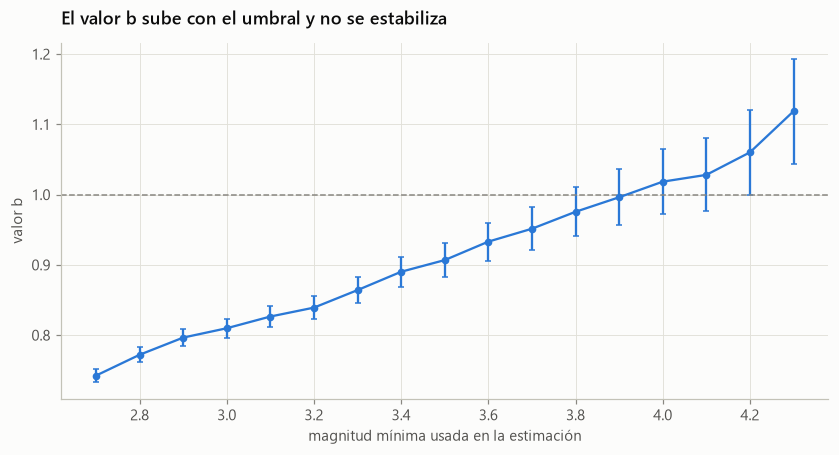

In [6]:
magnitudes = csn["magnitud"]
mc_curvatura = sismos.magnitud_completitud(magnitudes)
print(f"Magnitud de completitud por máxima curvatura: {mc_curvatura:.1f}")

umbrales = np.round(np.arange(2.7, 4.35, 0.1), 1)
estabilidad = pd.DataFrame([sismos.ajustar_gutenberg_richter(magnitudes, m) for m in umbrales]).set_index("mc")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.errorbar(estabilidad.index, estabilidad["b"], yerr=1.96 * estabilidad["error_b"], color=COLORES[0], marker="o",
            markersize=4, capsize=2, linewidth=1.5)
ax.axhline(1, color=TINTA_TENUE, linestyle="--", linewidth=1)
ax.set_xlabel("magnitud mínima usada en la estimación")
ax.set_ylabel("valor b")
ax.set_title("El valor b sube con el umbral y no se estabiliza")
plt.show()

**El valor b depende del umbral.** Si el catálogo fuera homogéneo y completo desde cierta magnitud, el valor b debería estabilizarse al subir el umbral. Aquí sube de forma continua. La razón aparece al revisar qué escala de magnitud usa el CSN en cada rango.

In [7]:
rangos = pd.cut(csn["magnitud"], [2, 3, 3.5, 4, 4.5, 5, 6, 8], right=False)
escalas = csn.groupby(rangos, observed=True).agg(sismos=("id", "size"),
                                                  magnitud_local=("tipo_magnitud", lambda t: (t == "Ml").mean()))
escalas.index = escalas.index.astype(str)
escalas.style.format({"magnitud_local": "{:.0%}"})

,sismos,magnitud_local
magnitud,,
"[2.0, 3.0)",10864,100%
"[3.0, 3.5)",6407,100%
"[3.5, 4.0)",2894,100%
"[4.0, 4.5)",1157,85%
"[4.5, 5.0)",391,8%
"[5.0, 6.0)",131,2%
"[6.0, 8.0)",14,0%


El CSN usa magnitud local para todos los sismos bajo 4 y magnitud de momento para casi todos los que superan 4,5. Las dos escalas no son idénticas, así que el catálogo combina dos reglas de medición distintas justo en el rango donde se estima la pendiente. Además, la red detecta sismos pequeños mejor en el norte, donde tiene más estaciones, que en el sur.

Por eso se estima el valor b final desde magnitud 4, donde el catálogo está completo en todo el país y el tramo superior usa una sola escala.

Valor b desde magnitud 4.0: 1.02 ± 0.05, con 1,693 sismos


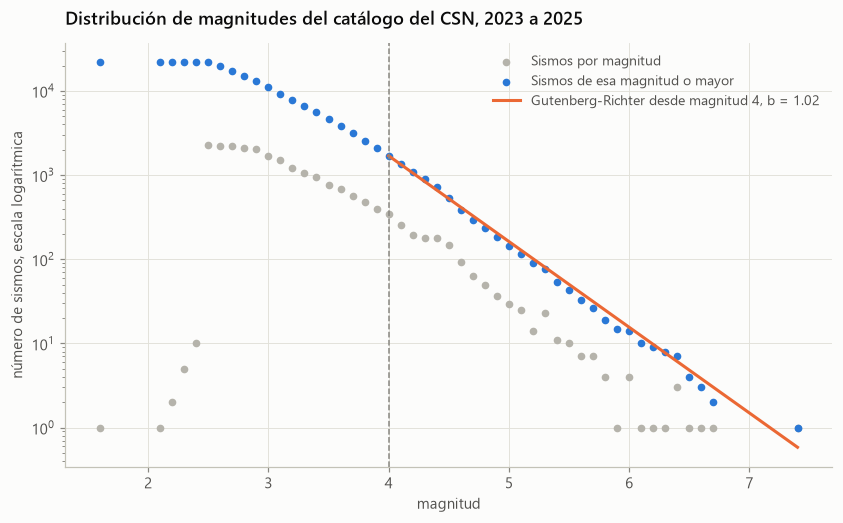

In [8]:
MC_FINAL = 4.0
ajuste = sismos.ajustar_gutenberg_richter(magnitudes, MC_FINAL)
print(f"Valor b desde magnitud {MC_FINAL:.1f}: {ajuste['b']:.2f} ± {1.96 * ajuste['error_b']:.2f}, con {ajuste['n']:,} sismos")

paso = 0.1
redondeadas = (magnitudes / paso).round() * paso
conteo = redondeadas.value_counts().sort_index()
acumulado = conteo[::-1].cumsum()[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(conteo.index, conteo.values, s=16, color=NEUTRO, label="Sismos por magnitud")
ax.scatter(acumulado.index, acumulado.values, s=16, color=COLORES[0], label="Sismos de esa magnitud o mayor")
x = np.linspace(MC_FINAL, redondeadas.max(), 50)
ax.plot(x, 10 ** (ajuste["a"] - ajuste["b"] * x), color=COLORES[1], linewidth=2,
        label=f"Gutenberg-Richter desde magnitud 4, b = {ajuste['b']:.2f}")
ax.axvline(MC_FINAL, color=TINTA_TENUE, linestyle="--", linewidth=1)
ax.set_yscale("log")
ax.set_xlabel("magnitud")
ax.set_ylabel("número de sismos, escala logarítmica")
ax.set_title("Distribución de magnitudes del catálogo del CSN, 2023 a 2025")
ax.legend(loc="upper right", fontsize=9)
fig.savefig(FIGURAS / "gutenberg_richter.png", bbox_inches="tight")
plt.show()

**Lectura.** Desde magnitud 4, el catálogo sigue bien la ley de Gutenberg-Richter con un valor b cercano a 1, el valor típico de las zonas de subducción. Por cada sismo de magnitud 6 hay unos diez de magnitud 5 y unos cien de magnitud 4. Bajo magnitud 4, la pendiente estimada depende de decisiones del catálogo, como la escala de magnitud y la cobertura de la red. Validar un catálogo antes de modelarlo evita conclusiones equivocadas.

## 5. Validación contra el USGS

Se busca, para cada sismo del USGS, el sismo del CSN más cercano en el tiempo. Se acepta la pareja si ocurren a menos de 30 segundos y a menos de 100 km.

El recuadro usado para consultar al USGS es un rectángulo, así que incluye zonas de Argentina, Bolivia y Perú. El CSN solo reporta de forma sistemática los sismos de Chile y su costa, por eso la cobertura se revisa por país.

In [9]:
pares = sismos.emparejar_catalogos(csn, usgs, segundos=30, km=100)
usgs["encontrado"] = usgs["id"].isin(pares["id"])
# El USGS describe la ubicación en inglés, terminando con el país: "80 km WSW of Vallenar, Chile".
usgs["pais"] = usgs["lugar"].str.extract(r",\s*([^,]+)$", expand=False).str.strip().fillna("Mar abierto")
por_pais = usgs.groupby("pais").agg(sismos_usgs=("id", "size"), encontrados_en_csn=("encontrado", "mean"))
por_pais.sort_values("sismos_usgs", ascending=False).style.format({"encontrados_en_csn": "{:.0%}"})

,sismos_usgs,encontrados_en_csn
pais,,
Chile,1691,98%
Argentina,714,63%
Peru,124,68%
Bolivia,104,17%
Mar abierto,17,76%


In [10]:
chile = usgs[usgs["pais"] == "Chile"].copy()
chile["tramo"] = pd.cut(chile["magnitud"], [2.5, 3.5, 4.0, 4.5, 5.0, 10], right=False,
                        labels=["2,5 a 3,5", "3,5 a 4", "4 a 4,5", "4,5 a 5", "5 o más"])
print(f"Sismos del USGS ubicados en Chile encontrados en el CSN: {chile['encontrado'].mean():.1%}")
chile.groupby("tramo", observed=True).agg(sismos_usgs=("id", "size"), encontrados_en_csn=("encontrado", "mean")).style.format(
    {"encontrados_en_csn": "{:.0%}"})

Sismos del USGS ubicados en Chile encontrados en el CSN: 98.4%


,sismos_usgs,encontrados_en_csn
tramo,,
"2,5 a 3,5",8,100%
"3,5 a 4",65,100%
"4 a 4,5",1155,98%
"4,5 a 5",350,98%
5 o más,113,99%


distancia mediana entre epicentros, km   10.36
desfase mediano en segundos               0.74
magnitud USGS menos CSN, mediana          0.10
correlación de magnitudes                 0.84


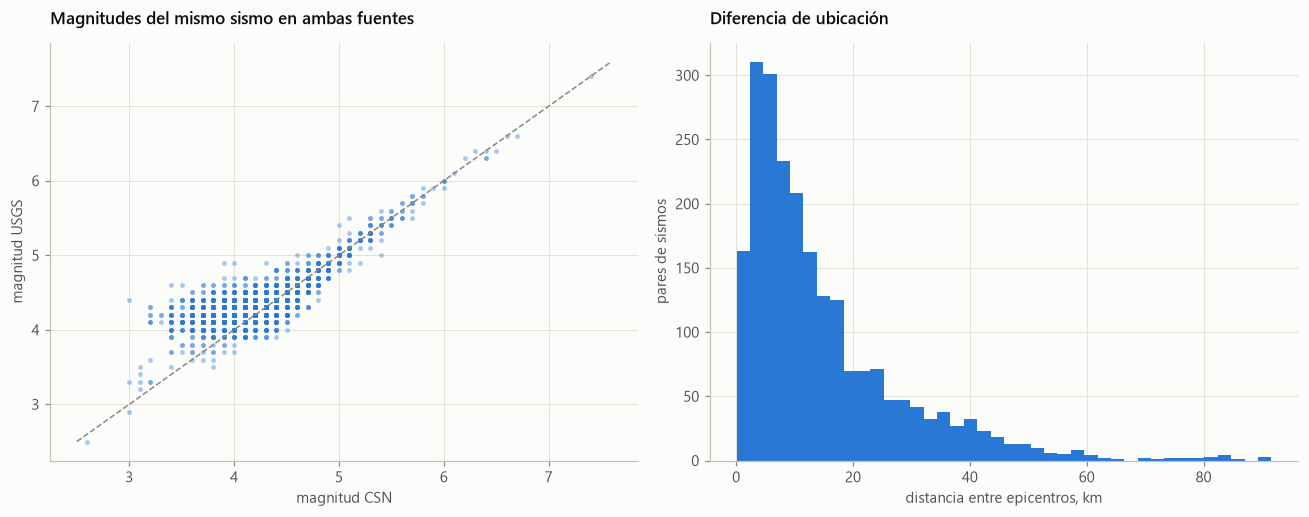

In [11]:
pares["diferencia_magnitud"] = pares["magnitud"] - pares["magnitud_csn"]
resumen_pares = pd.Series({
    "distancia mediana entre epicentros, km": pares["distancia_km"].median(),
    "desfase mediano en segundos": pares["desfase_s"].abs().median(),
    "magnitud USGS menos CSN, mediana": pares["diferencia_magnitud"].median(),
    "correlación de magnitudes": pares[["magnitud", "magnitud_csn"]].corr().iloc[0, 1],
})
print(resumen_pares.round(2).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
ax1.scatter(pares["magnitud_csn"], pares["magnitud"], s=10, color=COLORES[0], alpha=0.4, linewidths=0)
limites = [2.5, 7.6]
ax1.plot(limites, limites, color=TINTA_TENUE, linestyle="--", linewidth=1)
ax1.set_xlabel("magnitud CSN")
ax1.set_ylabel("magnitud USGS")
ax1.set_title("Magnitudes del mismo sismo en ambas fuentes", fontsize=11)
ax2.hist(pares["distancia_km"], bins=40, color=COLORES[0])
ax2.set_xlabel("distancia entre epicentros, km")
ax2.set_ylabel("pares de sismos")
ax2.set_title("Diferencia de ubicación", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURAS / "validacion_usgs.png", bbox_inches="tight")
plt.show()

**Lectura.**

- **El CSN es mucho más completo.** Registra trece veces más sismos que el USGS dentro de Chile, porque su red local detecta sismos pequeños que las estaciones lejanas no captan.
- **Casi no pierde sismos.** Encuentra el 98% de los sismos que el USGS ubica en Chile, en todos los rangos de magnitud. La baja cobertura en Argentina y Bolivia es esperable, porque esos sismos quedan fuera de su responsabilidad.
- **Ubicaciones consistentes.** La distancia mediana entre epicentros es de unos 10 km, y el tiempo de origen difiere en menos de un segundo.
- **Magnitudes comparables sobre 5.** Sobre magnitud 5 ambas fuentes usan magnitud de momento y coinciden. Entre 3,5 y 5 el USGS usa sobre todo magnitud de ondas de cuerpo, que se concentra entre 4 y 4,6 y genera la nube horizontal del gráfico.

## 6. Conclusiones

1. **El scraping produce un catálogo confiable.** Tras la limpieza no hay duplicados ni datos faltantes, y la validación contra el USGS encuentra el 98% de sus sismos en Chile.
2. **La sismicidad dibuja la subducción.** Los epicentros se hacen más profundos hacia el este, siguiendo la placa de Nazca bajo el continente.
3. **El norte concentra la actividad.** Cerca de dos tercios de los sismos registrados ocurren al norte de la latitud 27 sur.
4. **Gutenberg-Richter se cumple sobre magnitud 4, con b cercano a 1.** Bajo ese umbral, el cambio de escala de magnitud y la cobertura desigual de la red sesgan la estimación.

## 7. Limitaciones

- **Tres años de datos.** Es suficiente para la ley de Gutenberg-Richter, pero no para estudiar ciclos de grandes terremotos, que en Chile se repiten en escalas de décadas.
- **Escalas de magnitud distintas.** El CSN usa sobre todo magnitud local y el USGS magnitud de ondas de cuerpo. Compararlas directamente introduce diferencias que no son errores.
- **Scraping.** La extracción depende de la estructura HTML del sitio. Si el CSN la cambia, el extractor necesitará ajustes; las pruebas del paquete detectan ese tipo de cambio.